# Inner-Boundary Magnetic Field Map (ZDI-Style Starter)

This example loads the 3D BATSRUS sample, samples the **inner boundary shell** (`R=1`) using the library, and makes lat/lon magnetic maps.

The notebook is intentionally thin: it uses library helpers for shell sampling and plotting instead of reimplementing the workflow in cells.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt

from starwinds_analysis.smart_ds import SmartDs
from starwinds_analysis.data.samples import get_sample
from starwinds_analysis.analysis.shell_magnetic import (
    plot_magnetic_zdi_triplet,
    plot_shell_tangential_vectors_lonlat,
    sample_shell_magnetic_field_map,
    summarize_shell_magnetic_field_map,
)

plt.rcParams['figure.dpi'] = 120


## Load the 3D Sample and Configure the Radius Scale

We feed the stellar radius into the BATSRUS/griblet graph near the top so SI conversions are available consistently.

In [ ]:
DATA_FILE = Path(get_sample('3d__var_1_n00060000.plt'))
STAR_RADIUS_M = 696_000_000.0

print('Using:', DATA_FILE)
sds = SmartDs.from_file(DATA_FILE)
sds.add_batsrus_graph(body_radius_m=STAR_RADIUS_M)
body_radius_m = STAR_RADIUS_M


# TODO do you just delete tehse todos or what? I told you to use print(sds).
print(sds)
print(f'Body radius [m]: {body_radius_m:.6e}')


Using: /Users/dagfev/Documents/starwinds/starwinds-analysis/sample_data/3d__var_1_n00060000.plt
Title: BATSRUS: 3D Data, 2011/02/16 17:26:00.000
Zone : 3D   N=0060000
Points: 794624
Variables: 24
Body radius [m]: 6.960000e+08


## Sample the Inner Boundary Shell (`R = 1`)

This returns radial/azimuthal/meridional/tangential magnetic components on a regular spherical sampling grid.

- Internal field values are SI (`T`)
- Plotting unit is chosen separately (below we use `G`)

In [ ]:
R_BOUNDARY = 1.0
N_POLAR = 64
N_AZIMUTH = 128
B_PLOT_UNIT = 'G'

# TODO what is this shite function? You are doing it exactly the wrong way.
shell_b = sample_shell_magnetic_field_map(
    sds,
    R_BOUNDARY,
    n_polar=N_POLAR,
    n_azimuth=N_AZIMUTH,
    method='nearest',
    length_unit_to_m=body_radius_m,
)

print('Shell grid shape (theta, phi):', shell_b.theta.shape)
print('Radius:', shell_b.radius)
summary = summarize_shell_magnetic_field_map(shell_b, unit=B_PLOT_UNIT)
print('Finite B_r cells:', summary['finite_B_r_cells'], '/', summary['total_cells'])


Shell grid shape (theta, phi): (64, 128)
Radius: 1.0
Finite B_r cells: 8192 / 8192


## ZDI-Style Component Maps (Radial / Azimuthal / Meridional)

Conventions used here:

- **Radial**: outward normal component (`B_r`)
- **Azimuthal**: `+phi` direction (eastward on the lat/lon map)
- **Meridional**: northward tangent component (`-B_theta`) so it follows latitude intuition

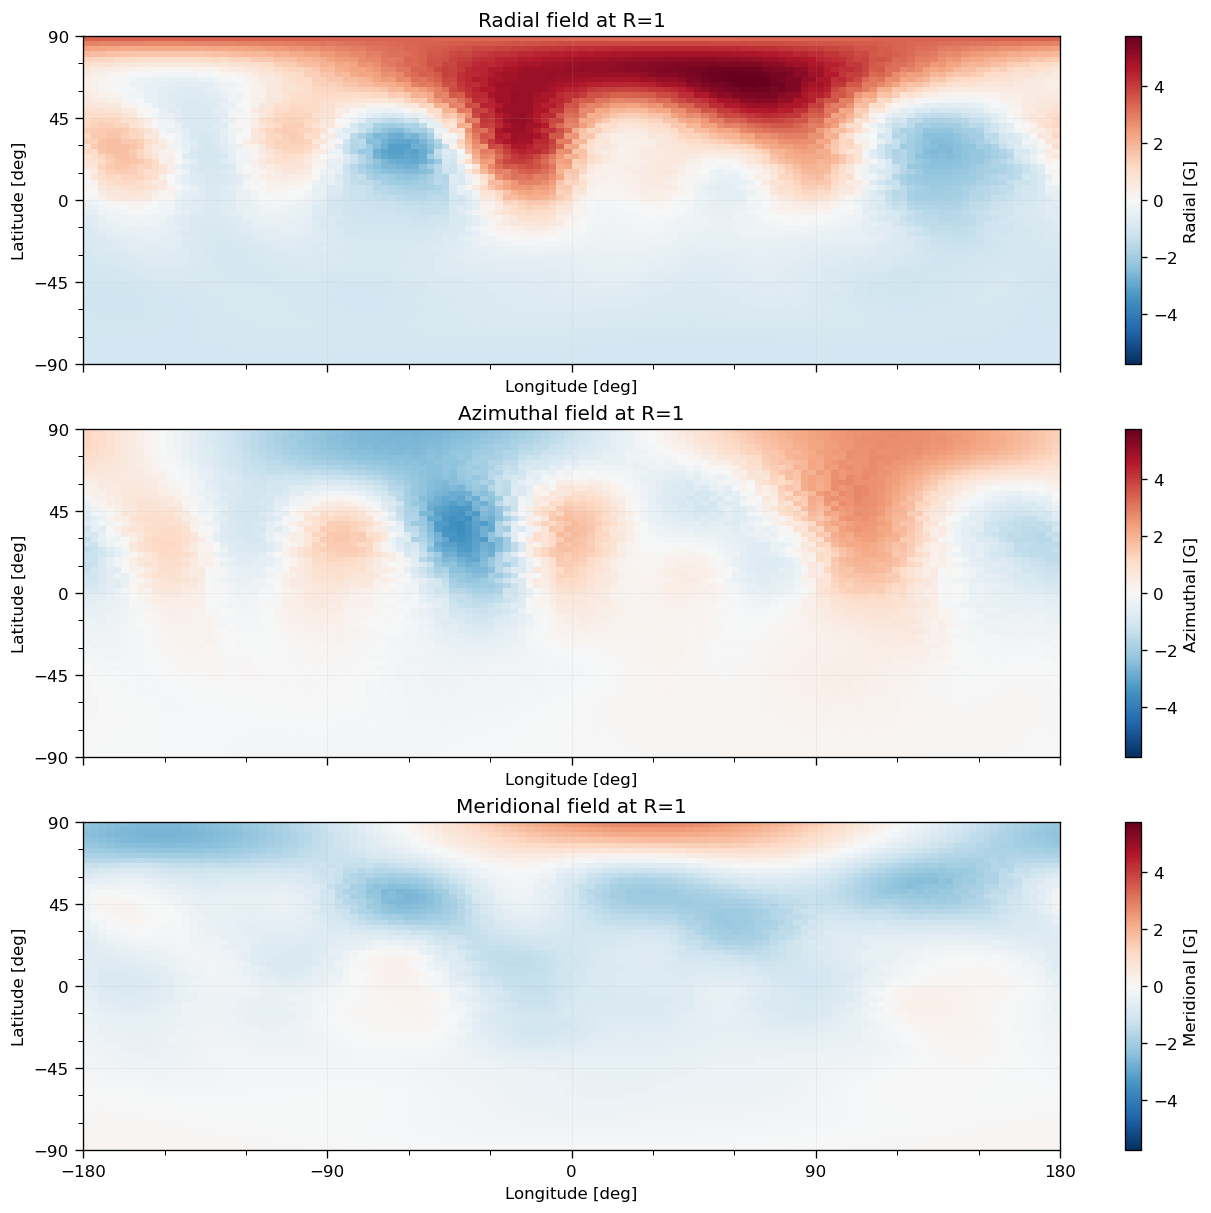

In [6]:
fig, axes = plot_magnetic_zdi_triplet(shell_b, unit=B_PLOT_UNIT, figsize=(10, 10))
plt.show()


## Tangential Field as Vectors on a Lat/Lon Map

This plot shows the tangential field in two ways:

- **Background color**: tangential magnetic strength `|B_tan|`
- **Arrows**: tangential field direction in the local surface tangent plane

Arrow meaning (important):

- Arrow **direction** follows the tangential field direction (`B_phi`, meridional)
- Arrow **length is normalized** (fixed plotting length), so it does **not** encode field magnitude
- Tangential field magnitude is encoded by the background colors
- The east-west arrow component is corrected by `cos(latitude)` so the direction is sensible on a lon/lat map

Non-positive |B_tan| cells shown with under-color: 0


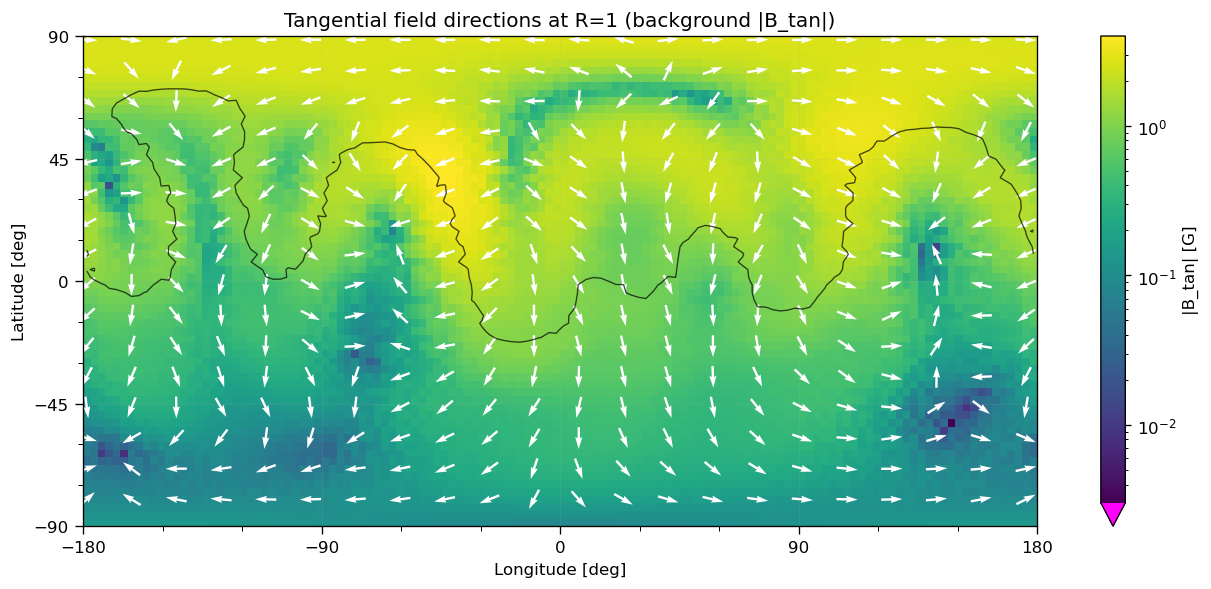

In [ ]:
#TODO did you sthink it was a good idea to hide this in a function?
fig, ax, extra = plot_shell_tangential_vectors_lonlat(
    shell_b,
    unit=B_PLOT_UNIT,
    background='tangential',
    background_scale='positive_log',
    arrow_stride=(4, 6),
    normalize_arrows=True,
    arrow_length_deg=8.0,
    overlay_radial_zero_contour=True,
)
ax.set_title(f"Tangential field directions at R={shell_b.radius:g} (background |B_tan|)")

if 'n_nonpositive' in extra:
    print('Non-positive |B_tan| cells shown with under-color:', extra['n_nonpositive'])

plt.show()


## Quick Boundary Summary (Useful Extra)

A few easy quantities to compute from the same shell sample:

- signed radial flux (should be small for a closed spherical surface in a divergence-free field)
- unsigned radial flux
- RMS strengths of radial / azimuthal / meridional / tangential components

In [8]:
summary = summarize_shell_magnetic_field_map(shell_b, unit=B_PLOT_UNIT)
summary


{'finite_B_r_cells': 8192,
 'total_cells': 8192,
 'signed_radial_flux [Wb]': 19083881199956.594,
 'signed_flux_coverage [none]': 1.0,
 'unsigned_radial_flux [Wb]': 741967211747814.2,
 'unsigned_flux_coverage [none]': 1.0,
 'rms_B_r [G]': 1.9242732585538098,
 'rms_B_azimuthal [G]': 0.9995292744262194,
 'rms_B_meridional [G]': 0.924371211968201,
 'rms_|B_tan| [G]': 1.361440747131716}

## Easy Follow-Ups

- compare two timesteps side-by-side using the same plotting helpers
- switch `background="radial"` in the vector plot to show tangential arrows over radial polarity
- repeat at `R > 1` to see how the magnetic topology opens with height